# ¿Cómo respondieron el empleo, la inflación y el crédito en España a las subidas de tipos del BCE entre 2022 y 2024?

Entre 2022 y 2024, el Banco Central Europeo ejecutó uno de los ciclos de subidas de tipos más agresivos de su historia, elevando el tipo de depósito desde el -0,5% hasta el 4%. Este análisis examina cómo respondieron el crédito, la inflación y el empleo en España a esa política monetaria restrictiva.

In [1]:
# Importación de librerías
import pandas as pd
import plotly.express as px
from pathlib import Path
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import requests
from io import StringIO

# ECB API


In [2]:
# Defino la ventana temporal del análisis
inicio = "2022-01"
fin = "2024-12"

In [3]:
def get_ecb_series(key: str, name: str, start_date, end_date):
    params = {
        "startPeriod": start_date,
        "endPeriod": end_date,
        "format": "csvdata"
    }
    dataset = key.split(".")[0]
    if dataset == "M":
        dataset = "MIR"
        series_key = series_key = ".".join(key.split(".")[0:])
    else:
        series_key = ".".join(key.split(".")[1:])
    url = f"https://data-api.ecb.europa.eu/service/data/{dataset}/" + series_key
    response = requests.get(url, params=params)
    df = pd.read_csv(StringIO(response.text)).set_index('TIME_PERIOD')
    df = df.rename(columns={'OBS_VALUE': name})
    return df[[name]]


In [4]:
dic = {}

ecb_keys = {
    "M.ES.B.A2C.A.B.A.2250.EUR.N": "imp_hog_hip", 
    "M.ES.B.A2C.AM.R.A.2250.EUR.N": "imp_hog_cons",
    "M.ES.B.A2B.A.R.A.2250.EUR.N": "int_hog",
    "M.ES.B.A2A.A.B.A.2240.EUR.P": "imp_emp",
    "M.ES.B.A2I.AM.R.A.2240.EUR.N": "int_emp",
    "FM.D.U2.EUR.4F.KR.DFR.LEV": "ecb_rates",
    "HICP.M.ES.N.000000.4D0.ANR": "ipc_gen_esp",
    "HICP.M.ES.N.XEF000.4D0.ANR": "ipc_sub_esp",
    "LFSI.M.ES.S.UNEHRT.TOTAL0.15_74.T": "desemp_esp"
    }

for key in ecb_keys:
    if not Path(f"data/{ecb_keys[key]}.csv").exists():
        data = get_ecb_series(key, ecb_keys[key], inicio, fin)
        data.to_csv(f"data/{ecb_keys[key]}.csv")
    
    dic[ecb_keys[key]] = pd.read_csv(f"data/{ecb_keys[key]}.csv", index_col = 0, parse_dates=True)

In [5]:
dic['ecb_rates'] = dic['ecb_rates'].resample("MS").mean()

In [6]:
df = pd.concat(dic, axis=1, sort=True)
df.columns = df.columns.get_level_values(0)

## Visualizaciones

In [7]:
f_hog_max = df.loc[inicio:fin].int_hog.idxmax()
f_hog_min = df.loc[inicio:fin].int_hog.idxmin()
hog_max = df.loc[inicio:fin].int_hog.max()
hog_min = df.loc[inicio:fin].int_hog.min()

f_emp_max = df.loc[inicio:fin].int_emp.idxmax()
f_emp_min = df.loc[inicio:fin].int_emp.idxmin()
emp_max = df.loc[inicio:fin].int_emp.max()
emp_min = df.loc[inicio:fin].int_emp.min()

f_ecb_max = df.loc[inicio:fin].ecb_rates.idxmax()
f_ecb_min = df.loc[inicio:fin].ecb_rates.idxmin()
ecb_max = df.loc[inicio:fin].ecb_rates.max()
ecb_min = df.loc[inicio:fin].ecb_rates.min()

#### Transmisión de la política monetaria al crédito
El primer mecanismo de transmisión de la política monetaria es el tipo de interés aplicado a nuevas operaciones de crédito. Si las subidas del BCE se trasladan rápidamente a hogares y empresas, el encarecimiento del crédito desincentiva el consumo y la inversión, reduciendo la demanda agregada y, con ella, la inflación.

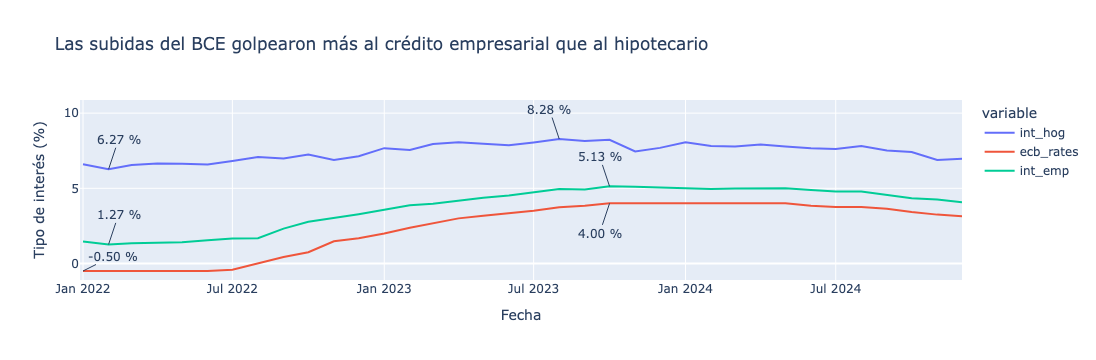

In [8]:
fig = px.line(df.loc[inicio:fin], y=['int_hog', 'ecb_rates', 'int_emp'],
        labels={"value": "Tipo de interés (%)", "TIME_PERIOD": "Fecha"}, title='Las subidas del BCE golpearon más al crédito empresarial que al hipotecario')

fig.add_annotation(x=f_hog_max, y=hog_max, text=f"{hog_max:.2f} %")
fig.add_annotation(x=f_hog_min, y=hog_min, text=f"{hog_min:.2f} %", ax=10)

fig.add_annotation(x=f_emp_max, y=emp_max, text=f"{emp_max:.2f} %")
fig.add_annotation(x=f_emp_min, y=emp_min, text=f"{emp_min:.2f} %", ax=10)

fig.add_annotation(x=f_ecb_max, y=ecb_max, text=f"{ecb_max:.2f} %", ay=30)
fig.add_annotation(x=f_ecb_min, y=ecb_min, text=f"{ecb_min:.2f} %", ax=30, ay=-15)


## Impacto sobre el volumen de crédito
El encarecimiento del crédito debería traducirse en una reducción de la demanda de financiación. Sin embargo, la respuesta de los distintos segmentos no fue homogénea: mientras el crédito hipotecario registró una contracción significativa, el crédito al consumo y el empresarial mostraron una evolución divergente.

In [9]:
# Normalizamos los datos para ver la evolución relativa de cada serie
df_norm = df.loc[inicio:fin].copy()
df_norm['imp_hog_hip'] = df_norm['imp_hog_hip'] / df_norm['imp_hog_hip'].iloc[0] * 100
df_norm['imp_hog_cons'] = df_norm['imp_hog_cons'] / df_norm['imp_hog_cons'].iloc[0] * 100
df_norm['imp_emp'] = df_norm['imp_emp'] / df_norm['imp_emp'].iloc[0] * 100


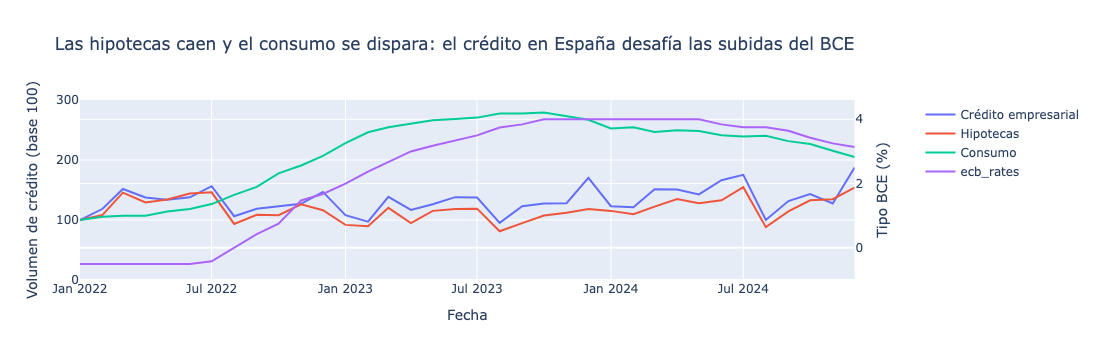

In [10]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(x=df.loc[inicio:fin].index, y=df_norm.loc[inicio:fin]['imp_emp'], name='Crédito empresarial'),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(x=df.loc[inicio:fin].index, y=df_norm.loc[inicio:fin]['imp_hog_hip'], name='Hipotecas'),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(x=df.loc[inicio:fin].index, y=df_norm.loc[inicio:fin]['imp_hog_cons'], name='Consumo'),
    secondary_y=False
)


fig.add_trace(
    go.Scatter(x=df.loc[inicio:fin].index, y=df_norm.loc[inicio:fin]['ecb_rates'], name='ecb_rates'),
    secondary_y=True
)

fig.update_yaxes(range=[-1, 4.6], secondary_y=True)

fig.update_yaxes(range=[0, 300], secondary_y=False)

fig.update_yaxes(title_text="Volumen de crédito (base 100)", secondary_y=False)
fig.update_yaxes(title_text="Tipo BCE (%)", secondary_y=True)
fig.update_xaxes(title_text="Fecha")
fig.update_layout(title="Las hipotecas caen y el consumo se dispara: el crédito en España desafía las subidas del BCE")

### Efecto sobre la inflación
El objetivo declarado del BCE era reducir la inflación hasta su objetivo del 2%. La inflación general, fuertemente influida por los precios energéticos, y la inflación subyacente, que excluye energía y alimentos no elaborados, siguieron trayectorias distintas durante el ciclo de subidas.

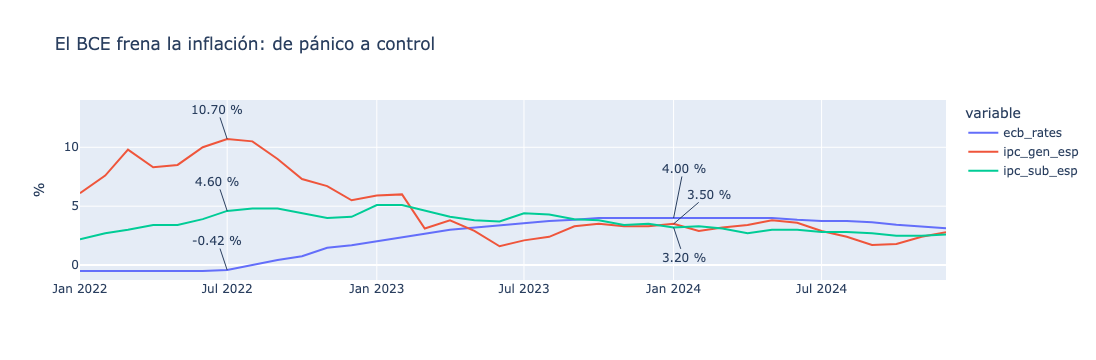

In [11]:
fig = px.line(df.loc[inicio:fin], y=['ecb_rates', 'ipc_gen_esp', 'ipc_sub_esp'],
        labels={"value": "%", "TIME_PERIOD": ""}, title='El BCE frena la inflación: de pánico a control')

fig.add_annotation(x='2022-07-01', y=df.loc['2022-07-01', 'ecb_rates'], text=f"{df.loc['2022-07-01', 'ecb_rates']:.2f} %")
fig.add_annotation(x='2022-07-01', y=df.loc['2022-07-01', 'ipc_gen_esp'], text=f"{df.loc['2022-07-01', 'ipc_gen_esp']:.2f} %")
fig.add_annotation(x='2022-07-01', y=df.loc['2022-07-01', 'ipc_sub_esp'], text=f"{df.loc['2022-07-01', 'ipc_sub_esp']:.2f} %")

fig.add_annotation(x='2024-01-01', y=df.loc['2024-01-01', 'ecb_rates'], text=f"{df.loc['2024-01-01', 'ecb_rates']:.2f} %", ay=-50, ax=10)
fig.add_annotation(x='2024-01-01', y=df.loc['2024-01-01', 'ipc_gen_esp'], text=f"{df.loc['2024-01-01', 'ipc_gen_esp']:.2f} %", ax=35)
fig.add_annotation(x='2024-01-01', y=df.loc['2024-01-01', 'ipc_sub_esp'], text=f"{df.loc['2024-01-01', 'ipc_sub_esp']:.2f} %", ay=30, ax=10)

fig.show()

### Impacto sobre el mercado laboral
La política monetaria restrictiva suele asociarse a una desaceleración económica y, en consecuencia, a un deterioro del mercado laboral. El caso español durante este período ofrece una lectura diferente.

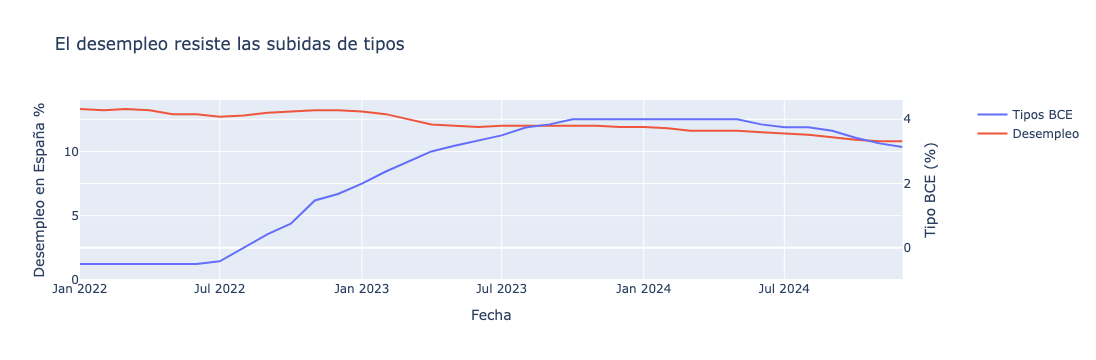

In [12]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(x=df.loc[inicio:fin].index, y=df.loc[inicio:fin]['ecb_rates'], name='Tipos BCE'),
    secondary_y=True
)

fig.add_trace(
    go.Scatter(x=df.loc[inicio:fin].index, y=df.loc[inicio:fin]['desemp_esp'], name='Desempleo'),
    secondary_y=False
)

fig.update_yaxes(range=[-1, 4.6], secondary_y=True)
fig.update_yaxes(range=[0, 14], secondary_y=False)

fig.update_yaxes(title_text="Desempleo en España %", secondary_y=False)
fig.update_yaxes(title_text="Tipo BCE (%)", secondary_y=True)
fig.update_xaxes(title_text="Fecha")
fig.update_layout(title="El desempleo resiste las subidas de tipos")

### Conclusiones
El ciclo de subidas del BCE entre 2022 y 2024 **logró su objetivo principal**: reducir la inflación desde máximos hasta niveles próximos al 2%. La transmisión al crédito fue clara, especialmente en el segmento hipotecario. Sin embargo, el mercado laboral español mostró una resiliencia notable, con una tasa de desempleo que continuó su tendencia descendente pese al endurecimiento monetario.

*Nota: Los datos se obtienen directamente de la API del BCE. La cobertura varía ligeramente según la serie; las series MIR y de desempleo tienen disponibilidad hasta marzo de 2026, las de inflación hasta abril de 2026.*